# mmFall Dataset — Easy Explorer & Dataset Decoder Guide

This notebook makes it **super easy** to navigate, understand, and visualize the **`mmFall`** dataset (`datasets/mmfall/data`).

---

### Why are there different folders?

| Folder | Name & Purpose | Contains | Fall Labels? |
| :--- | :--- | :--- | :--- |
| **`DS0`** | **Training Dataset** (2 Hours) | Long continuous unannotated walking/standing |  No falls (used for normal baseline training) |
| **`DS1`** | **Demo Illustration Dataset** | Short 1-minute recordings of 4 falls & normal activities | ℹ️ Dynamic Height Drop Detection ($\Delta Z_c > 0.6\text{m}$) |
| **`DS2`** | **Test Evaluation Dataset** | 35 individual trial files (150 falls + 200 ADL trials) |  **YES! Exact CSV timestamps for every fall** |

---

### ️ How to know what is a Fall vs. ADL?

Look at the **filename code** inside the `DS2` folder:

| Filename Code | Full Action Name | Category | Description |
| :--- | :--- | :--- | :--- |
| **`_bf_`** | **Backward Fall** | [FALL] | Person loses balance and falls backward onto floor |
| **`_ff_`** | **Forward Fall** | [FALL] | Person falls forward onto floor |
| **`_lf_`** | **Left Fall** | [FALL] | Person falls onto left side |
| **`_rf_`** | **Right Fall** | [FALL] | Person falls onto right side |
| **`_sf_`** | **Syncope / Slow Fall** | [FALL] | Fainting / slow collapse motion |
| **`_b_`** | **Bending** | [ADL] | Person bends down to pick up an object |
| **`_c_`** | **Crouching** | [ADL] | Person crouches down |
| **`_j_`** | **Jumping** | [ADL] | Person jumps up and down |


## 1. Master Dataset Catalog Table

Below is an automatically generated index table listing every single file, its human-readable action name, classification label (Fall vs ADL), duration, and number of fall events.


In [1]:
import glob
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

data_dir = Path("datasets/mmfall/data")
if not data_dir.exists():
    data_dir = Path("../datasets/mmfall/data")
if not data_dir.exists():
    data_dir = Path("../../datasets/mmfall/data")

# Action Code Decoder Lookup
action_decoder = {
    "bf": ("Backward Fall", "[FALL]"),
    "ff": ("Forward Fall", "[FALL]"),
    "lf": ("Left Fall", "[FALL]"),
    "rf": ("Right Fall", "[FALL]"),
    "sf": ("Syncope / Slow Fall", "[FALL]"),
    "b": ("Bending", "[ADL] Non-Fall"),
    "c": ("Crouching", "[ADL] Non-Fall"),
    "j": ("Jumping", "[ADL] Non-Fall")
}

npy_files = sorted(list(data_dir.rglob("*.npy")))
records = []

for p in npy_files:
    if p.stem in ["normal_test_data", "normal_train_data"]:
        continue
        
    folder = p.parent.name
    fname = p.stem
    csv_p = p.with_suffix(".csv")
    
   # Read fall event timestamps if CSV exists
    gt_markers = []
    if csv_p.exists():
        with open(csv_p, "r") as f:
            gt_markers = [int(line.strip()) for line in f if line.strip().isdigit()]
            
    action_name = "Normal ADL Motion"
    class_label = "[ADL] Non-Fall"
    
    if folder == "DS0":
        action_name = "2-Hour Continuous ADL Baseline"
    elif folder == "DS1":
        if "4falls" in fname:
            action_name = "4 Fall Demonstration Clip"
            class_label = "[FALL]"
        else:
            action_name = "Normal ADL Demonstration Clip"
    else:
       # DS2 decoding
        parts = fname.split("_")
        if len(parts) >= 2 and parts[1] in action_decoder:
            action_name, class_label = action_decoder[parts[1]]
            trial_num = parts[2] if len(parts) >= 3 else ""
            action_name = f"{action_name} (Trial {trial_num})"

    arr = np.load(p, allow_pickle=True)
    num_frames = len(arr)
    duration_s = round(num_frames / 10.0, 1)

    records.append({
        "Folder": folder,
        "File Name": fname,
        "Action Name": action_name,
        "Class Label": class_label,
        "Duration (s)": f"{duration_s}s",
        "Total Frames": num_frames,
        "Fall Events Count": len(gt_markers) if len(gt_markers) > 0 else ("Dynamic" if "fall" in fname.lower() else 0),
        "Fall Timestamps (s)": [f"{m/10.0:.1f}s" for m in gt_markers] if len(gt_markers) > 0 else "-"
    })

df_catalog = pd.DataFrame(records)
print(f"Total dataset files cataloged: {len(df_catalog)}")
df_catalog.head(15)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Total dataset files cataloged: 28


,Folder,File Name,Action Name,Class Label,Duration (s),Total Frames,Fall Events Count,Fall Timestamps (s)
0,DS0,DS0,2-Hour Continuous ADL Baseline,[ADL] Non-Fall,7603.1s,76031,0,-
1,DS1,DS1_4falls,4 Fall Demonstration Clip,[FALL],108.8s,1088,Dynamic,-
2,DS1,DS1_4normal,Normal ADL Demonstration Clip,[ADL] Non-Fall,104.3s,1043,0,-
3,DS2,DS2,Normal ADL Motion,[ADL] Non-Fall,6028.8s,60288,50,"[19.3s, 41.4s, 64.9s, 98.6s, 133.3s, 165.1s, 1..."
4,DS2,DS2_b_01,Bending (Trial 01),[ADL] Non-Fall,1008.5s,10085,0,-
5,DS2,DS2_bf_01,Backward Fall (Trial 01),[FALL],147.1s,1471,5,"[19.3s, 41.4s, 64.9s, 98.6s, 133.3s]"
6,DS2,DS2_bf_02,Backward Fall (Trial 02),[FALL],136.9s,1369,5,"[18.0s, 45.7s, 74.6s, 96.9s, 117.4s]"
7,DS2,DS2_bf_03,Backward Fall (Trial 03),[FALL],142.5s,1425,5,"[19.8s, 42.4s, 61.8s, 85.1s, 112.8s]"
8,DS2,DS2_c_01,Crouching (Trial 01),[ADL] Non-Fall,261.2s,2612,0,-
9,DS2,DS2_c_02,Crouching (Trial 02),[ADL] Non-Fall,268.9s,2689,0,-


## 2. Side-by-Side Motion Comparison (Fall vs Crouching vs Jumping)

Why does a Fall differ from normal motions?
- **[FALL] (Backward/Forward)**: Sudden **height drop** ($Z \downarrow$) combined with a **Doppler velocity spike** ($v \uparrow$).
- **[ADL] Crouching**: Height drops slowly ($Z \downarrow$), but velocity remains **low** ($v \approx 0$).
- **[ADL] Jumping**: Velocity spikes ($v \uparrow$), but height returns to the standing position (no net height drop).


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


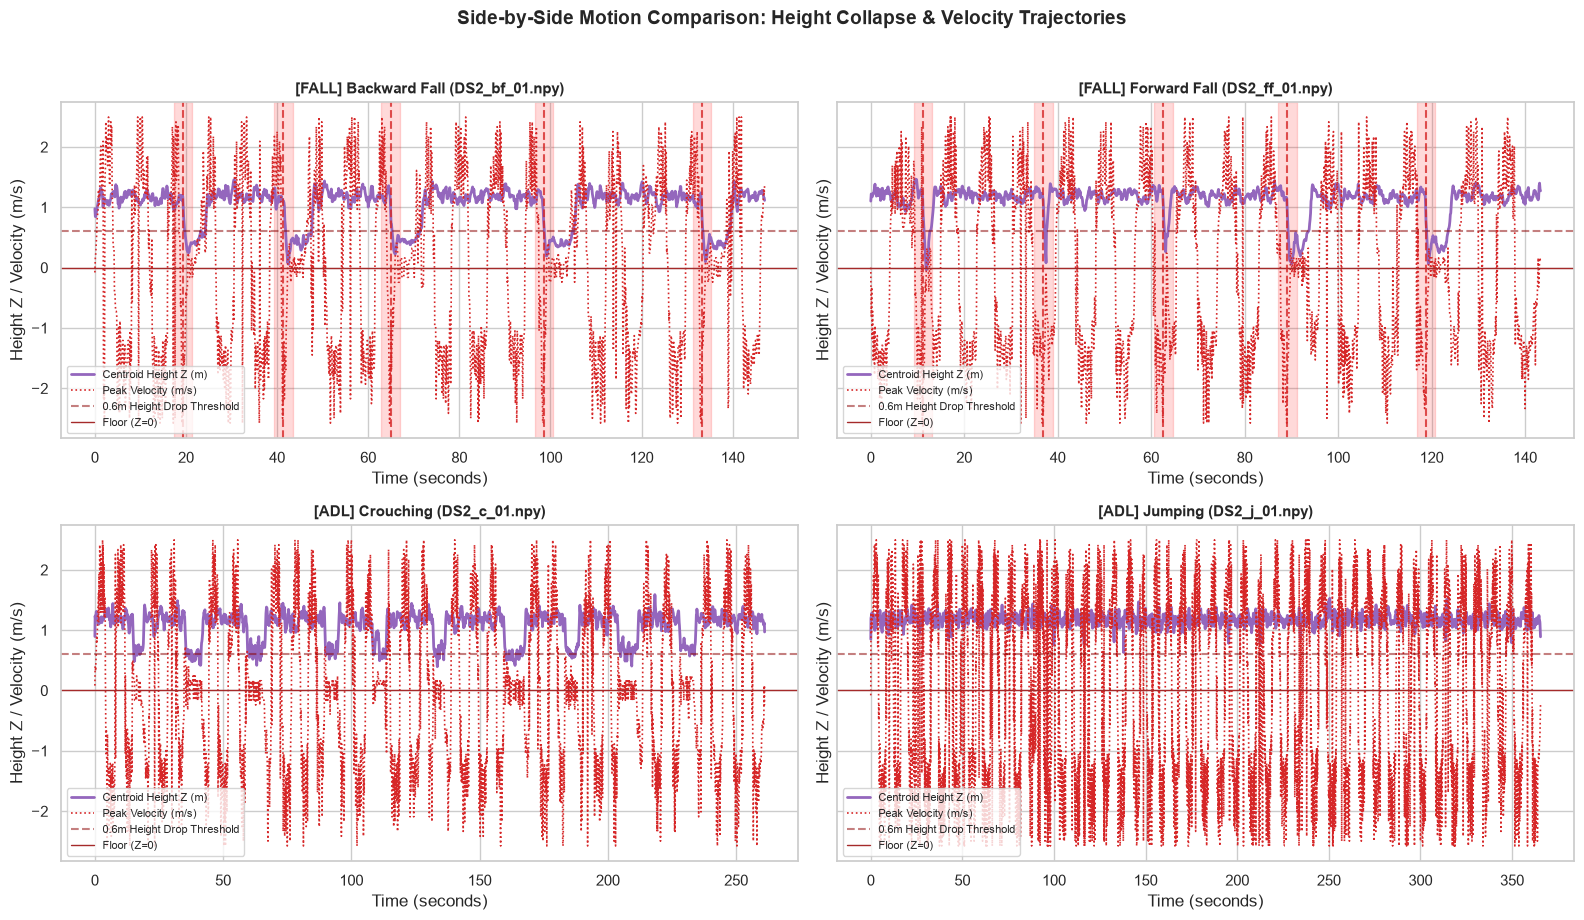

In [2]:
class MMfallSimpleParser:
    def __init__(self, height=1.80, tilt_angle_deg=10.0):
        self.height = height
        tilt_rad = np.deg2rad(tilt_angle_deg)
        self.rot_matrix = np.array([
            [1.0, 0.0, 0.0],
            [0.0, np.cos(tilt_rad), np.sin(tilt_rad)],
            [0.0, -np.sin(tilt_rad), np.cos(tilt_rad)]
        ])

    def parse(self, filepath: str) -> pd.DataFrame:
        arr = np.load(filepath, allow_pickle=True)
        records = []
        for frame_idx, frame in enumerate(arr):
            if frame is None or len(frame) == 0:
                continue
            p0 = frame[0]
            cx, cy, cz = p0[3], p0[4], p0[5]
            rot_c = np.matmul(self.rot_matrix, np.array([cx, cy, cz]))
            cz_room = rot_c[2] + self.height
            
            for p_idx, point in enumerate(frame):
                if len(point) < 15:
                    continue
                r, az, el, v, snr = point[9], point[10], point[11], point[12], point[13]
                xs = r * np.cos(el) * np.sin(az)
                ys = r * np.cos(el) * np.cos(az)
                zs = r * np.sin(el)
                rot = np.matmul(self.rot_matrix, np.array([xs, ys, zs]))
                records.append({
                    "frame": frame_idx,
                    "time_s": frame_idx / 10.0,
                    "x": rot[0],
                    "y": rot[1],
                    "z": rot[2] + self.height,
                    "centroid_z": cz_room,
                    "v": v,
                    "snr": snr
                })
        return pd.DataFrame(records)

simple_parser = MMfallSimpleParser()

compare_files = [
    ("DS2_bf_01.npy", "[FALL] Backward Fall"),
    ("DS2_ff_01.npy", "[FALL] Forward Fall"),
    ("DS2_c_01.npy", "[ADL] Crouching"),
    ("DS2_j_01.npy", "[ADL] Jumping")
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for idx, (fname, label) in enumerate(compare_files):
    fpath = str(data_dir / "DS2" / fname)
    if not os.path.exists(fpath):
        continue
        
    df_temp = simple_parser.parse(fpath)
    timeline = df_temp.groupby("frame").agg(
        centroid_z=("centroid_z", "first"),
        peak_v=("v", lambda x: x.iloc[np.argmax(np.abs(x))]),
        time_s=("time_s", "first")
    ).reset_index()
    
    csv_p = Path(fpath).with_suffix(".csv")
    gt_m = []
    if csv_p.exists():
        with open(csv_p, "r") as f:
            gt_m = [int(line.strip()) for line in f if line.strip().isdigit()]
            
    ax = axes[idx]
    ax.plot(timeline["time_s"], timeline["centroid_z"], color="tab:purple", linewidth=2.0, label="Centroid Height Z (m)")
    ax.plot(timeline["time_s"], timeline["peak_v"], color="tab:red", linestyle=":", linewidth=1.2, label="Peak Velocity (m/s)")
    ax.axhline(0.6, color="darkred", linestyle="--", alpha=0.5, label="0.6m Height Drop Threshold")
    ax.axhline(0.0, color="brown", linestyle="-", linewidth=1.0, label="Floor (Z=0)")
    
    for gm in gt_m:
        gt_t = gm / 10.0
        ax.axvspan(max(0, gt_t - 2.0), gt_t + 2.0, color="red", alpha=0.15)
        ax.axvline(gt_t, color="tab:red", linestyle="--", alpha=0.8)
        
    ax.set_title(f"{label} ({fname})", fontweight="bold", fontsize=11)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Height Z / Velocity (m/s)")
    ax.legend(loc="lower left", fontsize=8)

plt.suptitle("Side-by-Side Motion Comparison: Height Collapse & Velocity Trajectories", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 3. Easy Interactive Motion-Clip Viewer

Use the clean dropdown menus below:
1. **Action Recording**: Select any motion recording by its plain action name.
2. **Motion Clip**: Jump directly to isolated **10-second Fall vs ADL event clips**.
3. **Time Scrubber**: Slide smoothly through time (in seconds).


In [3]:
import ipywidgets as widgets

easy_file_map = {}
for idx, row in df_catalog.iterrows():
    folder = row["Folder"]
    fname = row["File Name"]
    action = row["Action Name"]
    prefix = "[FALL]" if "FALL" in row["Class Label"] else "[ADL]"
    lbl = f"{prefix} [{folder}] {action} ({fname})"
    path = str(data_dir / folder / f"{fname}.npy")
    easy_file_map[lbl] = path

easy_cache = {}

def get_easy_df(filepath: str) -> pd.DataFrame:
    if filepath not in easy_cache:
        easy_cache[filepath] = simple_parser.parse(filepath)
    return easy_cache[filepath]

def get_easy_clips(filepath: str):
    df = get_easy_df(filepath)
    if len(df) == 0:
        return {"Full Recording": (0, 100)}
        
    csv_p = Path(filepath).with_suffix(".csv")
    gt_markers = []
    if csv_p.exists():
        with open(csv_p, "r") as f:
            gt_markers = [int(line.strip()) for line in f if line.strip().isdigit()]
            
    max_f = int(df["frame"].max())
    opts = {"Full Recording (All Frames)": (0, max_f)}
    
    if len(gt_markers) > 0:
        for idx, gt_f in enumerate(gt_markers):
            start_f = max(0, gt_f - 50)
            end_f = min(max_f, gt_f + 50)
            gt_t = gt_f / 10.0
            opts[f"[FALL Clip {idx+1}] Impact @ {gt_t:.1f}s (Frames {start_f}-{end_f})"] = (start_f, end_f)
    elif "4falls" in Path(filepath).stem:
       # DS1_4falls dynamic detection: find height collapse drops
        timeline = df.groupby("frame")["centroid_z"].first()
        drop_1s = timeline.shift(5) - timeline.shift(-5)
        fall_frames = timeline[(timeline < 0.55) | (drop_1s > 0.5)].index.values
        if len(fall_frames) > 0:
           # Cluster nearby fall frames into 4 clips
            clusters = []
            curr = [fall_frames[0]]
            for f_val in fall_frames[1:]:
                if f_val - curr[-1] <= 40:
                    curr.append(f_val)
                else:
                    clusters.append(curr)
                    curr = [f_val]
            clusters.append(curr)
            
            for idx, cl in enumerate(clusters[:4]):
                mid_f = int(np.mean(cl))
                s_f = max(0, mid_f - 50)
                e_f = min(max_f, mid_f + 50)
                opts[f"[FALL Clip {idx+1}] Impact @ {mid_f/10.0:.1f}s (Frames {s_f}-{e_f})"] = (s_f, e_f)
    else:
        num_clips = max(1, max_f // 100)
        for idx in range(num_clips):
            s_f = idx * 100
            e_f = min(max_f, (idx + 1) * 100)
            opts[f"[ADL Clip {idx+1}] Normal Motion ({s_f/10.0:.1f}s - {e_f/10.0:.1f}s)"] = (s_f, e_f)
            
    return opts

# Widgets Setup
drop_file = widgets.Dropdown(
    options=list(easy_file_map.keys()),
    value=list(easy_file_map.keys())[0],
    description="Recording:",
    layout=widgets.Layout(width="70%")
)

init_fp = easy_file_map[drop_file.value]
init_clips = get_easy_clips(init_fp)

drop_clip = widgets.Dropdown(
    options=list(init_clips.keys()),
    value=list(init_clips.keys())[0],
    description="Motion Clip:",
    layout=widgets.Layout(width="70%")
)

c_s, c_e = init_clips[drop_clip.value]

slide_frame = widgets.IntSlider(
    min=c_s, max=c_e, step=1, value=c_s,
    description="Time Frame:", continuous_update=False,
    layout=widgets.Layout(width="70%")
)

def on_f_change(change):
    fp = easy_file_map[change["new"]]
    c_opts = get_easy_clips(fp)
    drop_clip.options = list(c_opts.keys())
    drop_clip.value = list(c_opts.keys())[0]
    cs, ce = c_opts[drop_clip.value]
    slide_frame.min = cs
    slide_frame.max = ce
    slide_frame.value = cs

def on_c_change(change):
    fp = easy_file_map[drop_file.value]
    c_opts = get_easy_clips(fp)
    if change["new"] in c_opts:
        cs, ce = c_opts[change["new"]]
        slide_frame.min = cs
        slide_frame.max = ce
        slide_frame.value = cs

drop_file.observe(on_f_change, names="value")
drop_clip.observe(on_c_change, names="value")

def render_easy_view(rec_key: str, clip_key: str, frame_idx: int):
    fp = easy_file_map[rec_key]
    df = get_easy_df(fp)
    
    if len(df) == 0:
        return
        
    csv_p = Path(fp).with_suffix(".csv")
    gt_markers = []
    if csv_p.exists():
        with open(csv_p, "r") as f:
            gt_markers = [int(line.strip()) for line in f if line.strip().isdigit()]
            
    max_f = int(df["frame"].max())
    frame_idx = min(max(frame_idx, 0), max_f)
    t_s = frame_idx / 10.0
    
    timeline = df.groupby("frame").agg(centroid_z=("centroid_z", "first"), time_s=("time_s", "first")).reset_index()
    curr_cz = timeline[timeline["frame"] == frame_idx]["centroid_z"].values[0] if len(timeline[timeline["frame"] == frame_idx]) else 1.8
    
   # 1s height drop calculation
    z_b = timeline[timeline["frame"] == max(0, frame_idx - 5)]["centroid_z"].values
    z_a = timeline[timeline["frame"] == min(max_f, frame_idx + 5)]["centroid_z"].values
    h_drop = (z_b[0] - z_a[0]) if len(z_b) > 0 and len(z_a) > 0 else 0.0
    
   # DUAL FALL EVALUATION RULE:
   # 1. Matches CSV Ground Truth timestamp window (+/- 2s) OR
   # 2. Dynamic Centroid Collapse (Height Z_c < 0.55m on floor OR 1s Height Drop > 0.50m)
    is_csv_fall = any(abs(frame_idx - gm) <= 20 for gm in gt_markers)
    is_dynamic_fall = (curr_cz < 0.55) or (h_drop > 0.50)
    
   # File type context
    is_fall_recording = "FALL" in rec_key or "bf" in fp or "ff" in fp or "lf" in fp or "rf" in fp or "sf" in fp or "4falls" in fp
    
    is_fall = (is_csv_fall or (is_dynamic_fall and is_fall_recording))
    
    df_f = df[df["frame"] == frame_idx]
    
    fig = plt.figure(figsize=(16, 5))
    
   # 3D Point Cloud View
    ax1 = fig.add_subplot(1, 3, 1, projection="3d")
    if len(df_f) > 0:
        sc1 = ax1.scatter(df_f["x"], df_f["y"], df_f["z"], c=df_f["v"], cmap="coolwarm", vmin=-3.0, vmax=3.0, s=40, edgecolors="k", linewidths=0.3)
        fig.colorbar(sc1, ax=ax1, shrink=0.6, pad=0.08, label="Doppler (m/s)")
    ax1.set_title(f"3D Room View @ {t_s:.1f}s", fontweight="bold", fontsize=10)
    ax1.set_xlabel("X (m)")
    ax1.set_ylabel("Y (m)")
    ax1.set_zlabel("Z (m)")
    ax1.set_xlim(-2.0, 2.0)
    ax1.set_ylim(0.0, 6.0)
    ax1.set_zlim(-0.5, 2.2)
    
   # Front View (Elevation)
    ax2 = fig.add_subplot(1, 3, 2)
    if len(df_f) > 0:
        ax2.scatter(df_f["x"], df_f["z"], c=df_f["v"], cmap="coolwarm", vmin=-3.0, vmax=3.0, s=40)
    ax2.axhline(0.0, color="brown", linestyle="-", linewidth=1.2, label="Floor (Z=0)")
    ax2.set_title("Front Elevation View (X vs Z)", fontweight="bold", fontsize=10)
    ax2.set_xlabel("X (Lateral, m)")
    ax2.set_ylabel("Z (Height, m)")
    ax2.set_xlim(-2.0, 2.0)
    ax2.set_ylim(-0.5, 2.2)
    ax2.legend(loc="upper right", fontsize=8)
    
   # Height Timeline
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.plot(timeline["time_s"], timeline["centroid_z"], color="tab:purple", linewidth=2.0, label="Centroid Z (m)")
    ax3.axhline(0.55, color="darkred", linestyle=":", linewidth=1.2, label="Floor Collapse Zone (Z<0.55m)")
    
    for gm in gt_markers:
        gt_t = gm / 10.0
        ax3.axvspan(max(0, gt_t - 2.0), gt_t + 2.0, color="red", alpha=0.2)
        ax3.axvline(gt_t, color="tab:red", linestyle="--")
        
    ax3.axvline(t_s, color="black", linestyle="--", linewidth=2.0, label=f"Current ({t_s:.1f}s)")
    ax3.set_title("Height Collapse Profile over Time", fontweight="bold", fontsize=10)
    ax3.set_xlabel("Time (seconds)")
    ax3.set_ylabel("Height Z (m)")
    ax3.legend(loc="lower left", fontsize=8)
    
    if is_fall:
        status_str = f"[FALL DETECTED / ON FLOOR] - Centroid Height Z = {curr_cz:.2f}m"
        status_col = "darkred"
    else:
        status_str = f"[NORMAL ADL MOTION] - Centroid Height Z = {curr_cz:.2f}m"
        status_col = "darkgreen"
        
    plt.suptitle(f"{rec_key} | Frame {frame_idx}/{max_f} ({t_s:.1f}s)\nSTATUS: {status_str}", fontweight="bold", fontsize=12, color=status_col, y=1.05)
    plt.tight_layout()
    plt.show()

ui_easy = widgets.VBox([drop_file, drop_clip, slide_frame])
out_easy = widgets.interactive_output(render_easy_view, {"rec_key": drop_file, "clip_key": drop_clip, "frame_idx": slide_frame})
display(ui_easy, out_easy)


C:\Users\joeyw\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Output()